In [10]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

from sympy import *
from sympy.core import S

In [11]:

k = symbols('omega', positive=True, real=True)
l = symbols('s', positive=True, real=True)

nu = symbols('nu', positive=True, real=True)

a = symbols('alpha', positive=True, real=True)

a = sqrt(pi) * gamma(nu + S(1)/S(2))/gamma(nu)
display(a)

E = (S(2)/pi) * (a**2 / (a**2 + k**2))**((S(1) + S(2)*nu) / S(2))

display(E.simplify())

R = integrate(E * cos(k * l), (k, 0, oo))

display(R.simplify())

SF = S(2) * limit(R, l, 0) - S(2) * R
#limit(R, l, 0) = 1

display(SF.simplify())

# Gives the same thing
#SF2 = 2 * integrate((1-cos(k*l))*E, (k, 0, oo))

b = symbols('b', positive=True, real=True)

eq_E = (1/b) * S(1)/S(2) * l**2 * diff(SF, l)

display(eq_E.simplify())


sqrt(pi)*gamma(nu + 1/2)/gamma(nu)

2*pi**(nu - 1/2)*(nu*gamma(nu + 1/2))**(2*nu + 1)*(pi*nu**2*gamma(nu + 1/2)**2 + omega**2*gamma(nu + 1)**2)**(-nu - 1/2)

(sqrt(pi)*nu*s*gamma(nu + 1/2)/(2*gamma(nu + 1)))**nu*(besseli(-nu, sqrt(pi)*s*gamma(nu + 1/2)/gamma(nu)) - besseli(nu, sqrt(pi)*s*gamma(nu + 1/2)/gamma(nu)))*gamma(1 - nu)

2**(1 - nu)*((2*gamma(nu + 1))**nu - (sqrt(pi)*nu*s*gamma(nu + 1/2))**nu*besseli(-nu, sqrt(pi)*s*gamma(nu + 1/2)/gamma(nu))*gamma(1 - nu) + (sqrt(pi)*nu*s*gamma(nu + 1/2))**nu*besseli(nu, sqrt(pi)*s*gamma(nu + 1/2)/gamma(nu))*gamma(1 - nu))/gamma(nu + 1)**nu

(s/2)**(nu + 1)*(sqrt(pi)*nu*gamma(nu + 1/2)/gamma(nu + 1))**nu*(-sqrt(pi)*s*besseli(1 - nu, sqrt(pi)*s*gamma(nu + 1/2)/gamma(nu))*gamma(nu + 1/2) - sqrt(pi)*s*besseli(-nu - 1, sqrt(pi)*s*gamma(nu + 1/2)/gamma(nu))*gamma(nu + 1/2) + sqrt(pi)*s*besseli(nu - 1, sqrt(pi)*s*gamma(nu + 1/2)/gamma(nu))*gamma(nu + 1/2) + sqrt(pi)*s*besseli(nu + 1, sqrt(pi)*s*gamma(nu + 1/2)/gamma(nu))*gamma(nu + 1/2) - 2*besseli(-nu, sqrt(pi)*s*gamma(nu + 1/2)/gamma(nu))*gamma(nu + 1) + 2*besseli(nu, sqrt(pi)*s*gamma(nu + 1/2)/gamma(nu))*gamma(nu + 1))*gamma(1 - nu)/(b*gamma(nu))

(1e-06, 10.0)

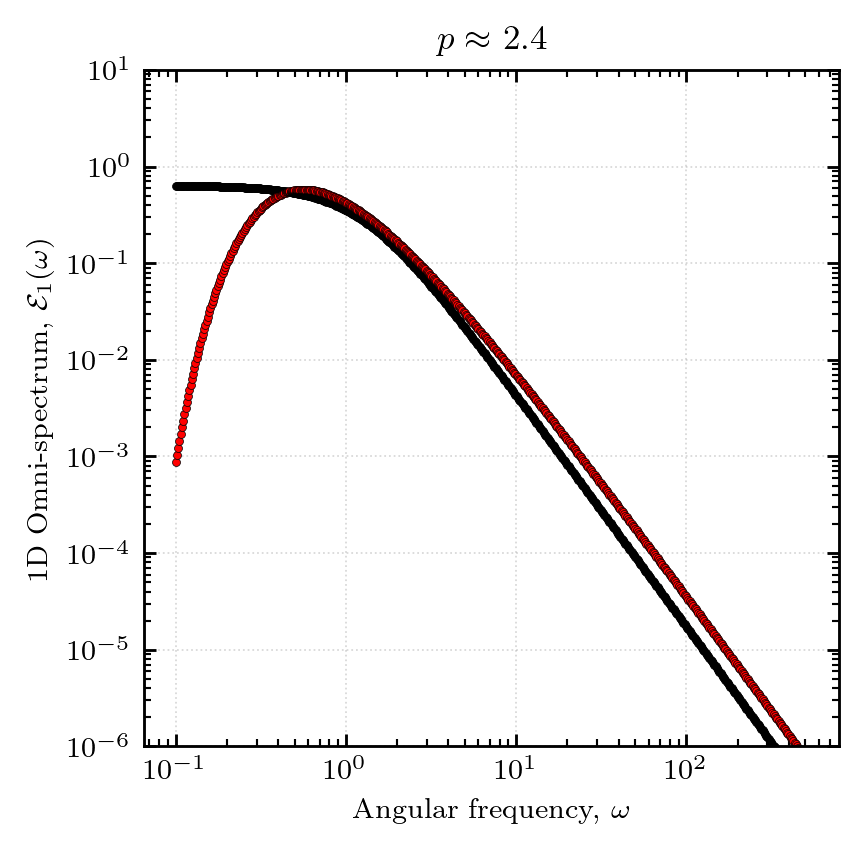

In [14]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

_k = np.exp(np.linspace(np.log(0.1), np.log(512), 512))
_nu = 0.7

for __k in _k:
    val = E.subs({k: __k, nu: _nu}).evalf()
    ax.scatter(__k, val, marker='o', s=5., color='black', zorder=2, linewidth=0.2, edgecolor='black')

    val1 = eq_E.subs({l: 1./__k, nu: _nu, b: 1.}).evalf()
    ax.scatter(__k, val1, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

ax.loglog()

ax.set_title(r'$p \approx$ %s' % (1. + 2.*_nu))

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'1D Omni-spectrum, $\mathcal{E}_1(\omega)$')
ax.set_xlabel(r'Angular frequency, $\omega$')

ax.set_ylim((1e-6, 1e1))


pi**(1/2 - nu/2)*(1/(2*omega))**(nu + 2)*(1/(nu*gamma(nu + 1/2)))**(nu + 1)*(pi*nu**2*gamma(nu + 1/2)**2 + omega**2*gamma(nu + 1)**2)**(nu + 1/2)*(-2*omega*besseli(-nu, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1) + 2*omega*besseli(nu, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1) - sqrt(pi)*besseli(1 - nu, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) - sqrt(pi)*besseli(-nu - 1, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) + sqrt(pi)*besseli(nu - 1, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) + sqrt(pi)*besseli(nu + 1, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2))*gamma(1 - nu)/(gamma(nu)*gamma(nu + 1)**nu)

/home/m/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: RuntimeWarning: invalid value encountered in cast
  return np.asarray(x, float)
/home/m/.local/lib/python3.10/site-packages/matplotlib/collections.py:196: RuntimeWarning: invalid value encountered in cast
  offsets = np.asanyarray(offsets, float)


Text(0.5, 0, 'Hurst parameter, $H$')

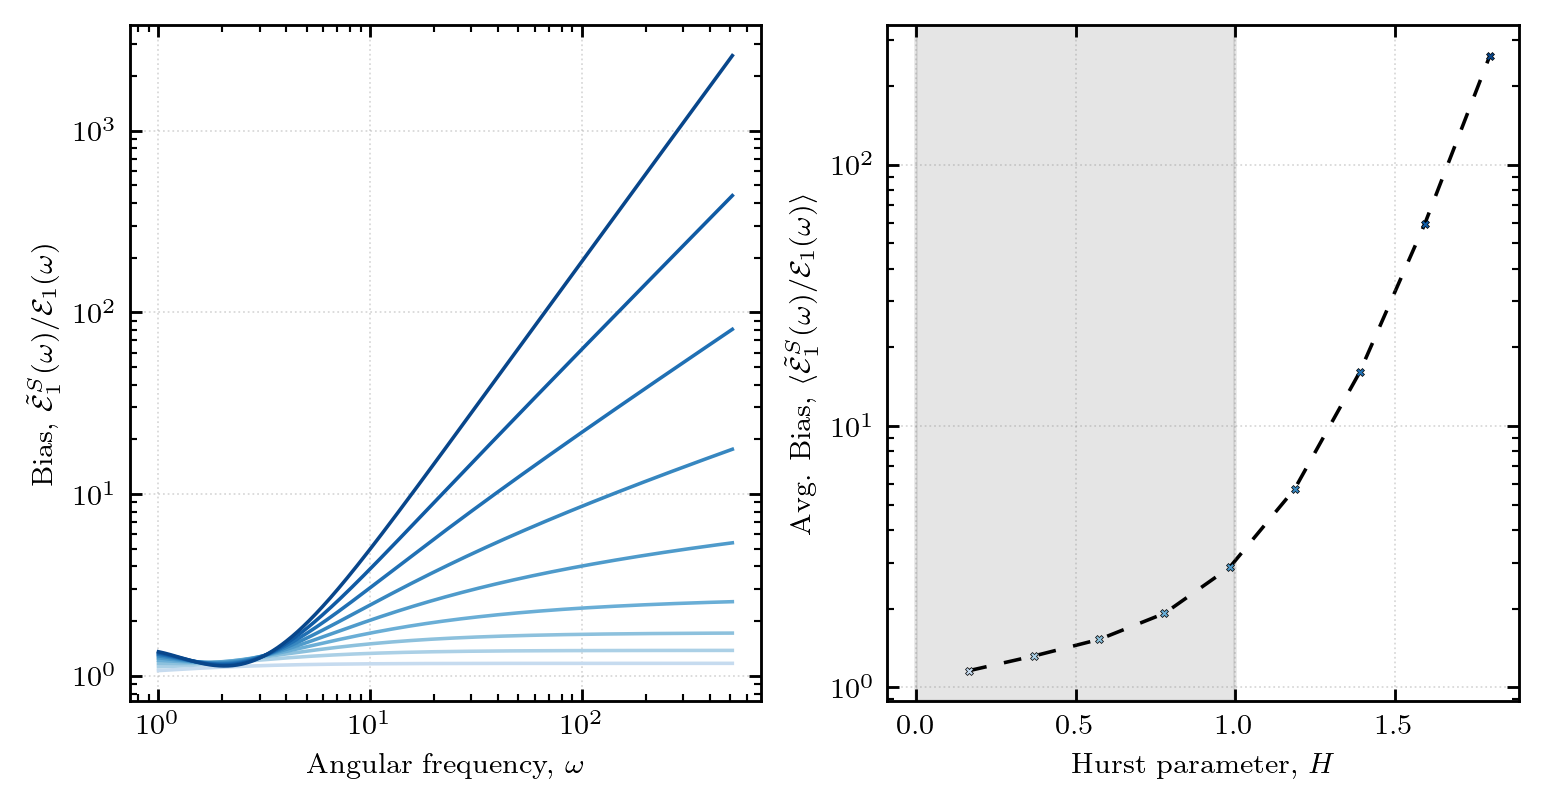

In [27]:
NUM = 10
cols = plt.get_cmap('Greys')(np.linspace(0.25, 1., NUM))
cols1 = plt.cm.Reds(np.linspace(0.25, 1., NUM))
cols2 = plt.cm.Blues(np.linspace(0.25, 1., NUM))
cols3 = plt.cm.Greens(np.linspace(0.25, 1., NUM))
upper_cmap = mpl.colors.LinearSegmentedColormap.from_list('Upper', cols2)

fig, ax = plt.subplots(1, 2, figsize=(7., 3.5), dpi=256)

ratio = eq_E.subs({l: 1/k, b: 1}) / E
display(ratio.simplify())

_k = np.exp(np.linspace(np.log(1), np.log(512), 512))
_nu = np.linspace(1./6., 2., NUM)

R1 = []
for i, __nu in enumerate(_nu):
    E1 = []
    E2 = []
    ER = []
    for __k in _k:
        val1 = E.subs({k: __k, nu: __nu}).evalf()
        E1.append(val1)
        val2 = eq_E.subs({l: 1./__k, nu: __nu, b: 1.}).evalf()
        E2.append(val2)
        val3 = ratio.subs({k: __k, nu: __nu}).evalf()
        ER.append(val3)

    E1 = np.array(E1)
    E2 = np.array(E2)
    R1.append(np.mean(np.array(ER)))

    ax[0].plot(_k, E2/E1, color=cols2[i], linewidth=1.)
    ax[1].scatter(__nu, np.mean(E2/E1), marker='X', s=5., color=cols2[i], zorder=2, linewidth=0.2, edgecolor='black')

ax[1].plot(_nu, R1, linewidth=1., color='black', zorder=1, linestyle=(0,(5,5)))

ax[1].axvspan(0, 1., alpha=0.2, color='gray', zorder=0)

ax[0].loglog()
ax[1].set_yscale('log')

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_ylabel(r'Bias, $\tilde{\mathcal{E}}_1^S(\omega)/\mathcal{E}_1(\omega)$')
ax[0].set_xlabel(r'Angular frequency, $\omega$')

ax[1].set_ylabel(r'Avg. Bias, $\langle \tilde{\mathcal{E}}_1^S(\omega)/\mathcal{E}_1(\omega) \rangle$')
ax[1].set_xlabel(r'Hurst parameter, $H$')
#ax.set_ylim((1e-6, 1e1))


Text(0.5, 0, '$\\lambda$')

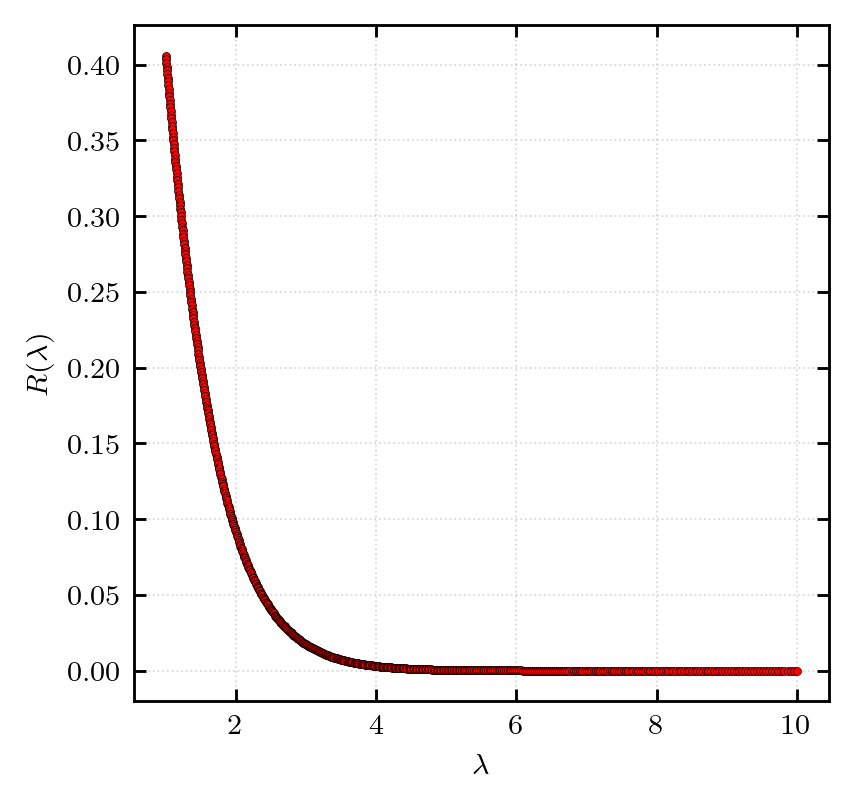

In [23]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

_l = np.exp(np.linspace(np.log(1), np.log(10), 512))
_nu = 1.5

for __l in _l:
    val = R.subs({l: __l, nu: _nu}).evalf()
    ax.scatter(__l, val, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'$R(\lambda)$')
ax.set_xlabel(r'$\lambda$')


Text(0.5, 0, '$\\lambda$')

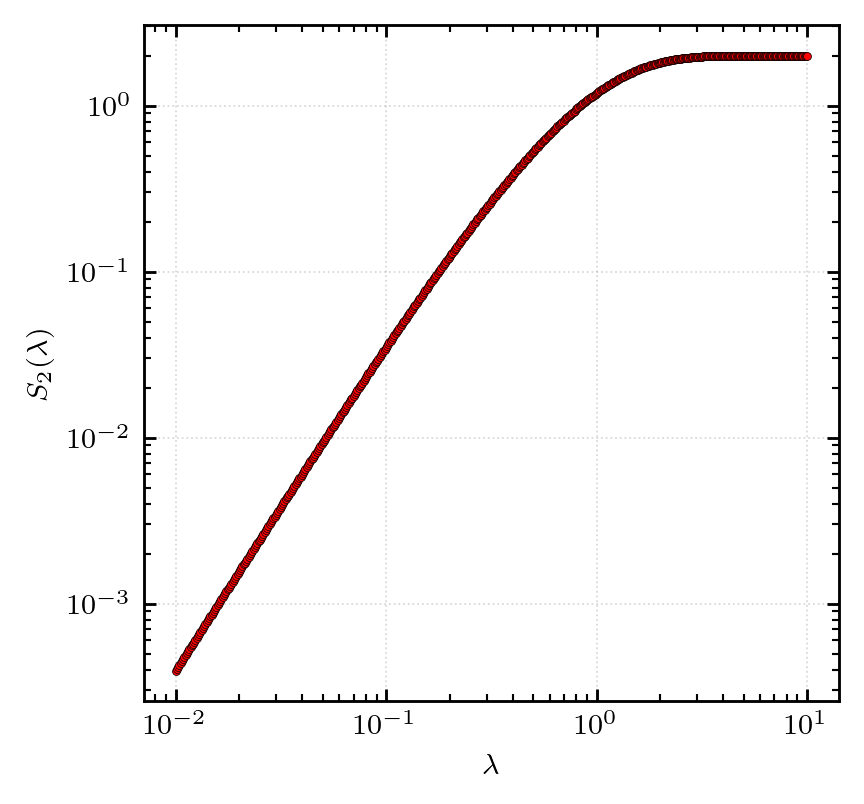

In [24]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

_l = np.exp(np.linspace(np.log(0.01), np.log(10), 512))
_nu = 1.5

for __l in _l:
    val = SF.subs({l: __l, nu: _nu}).evalf()
    ax.scatter(__l, val, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

ax.loglog()

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'$S_2(\lambda)$')
ax.set_xlabel(r'$\lambda$')
